# Unidad Didáctica 8 — Clasificación de Enfermedades Cardíacas
**Fundamentos de la Programación II — UAX**

**Participantes del grupo:**
- Participante 1 Alvaro
- Participante 2 Elena
- Participante 3 Valery

---

## Objetivo
Predecir si un paciente tiene enfermedad cardíaca a partir de datos clínicos, utilizando el dataset de Cleveland Clinic y validando con datos de otros tres hospitales.

## Estructura del notebook
| Sección | Responsable |
|---|---|
| 1. Carga y EDA | Participante 1 |
| 2. Preprocesamiento | Participante 1 |
| 3. Modelos y evaluación binaria | Participante 2 |
| 4. Clasificación multiclase | Participante 3 |
| 5. Generalización multi-hospital | Participante 3 |
| 6. Conclusiones | Participante 3 |

---
# SECCIÓN 1 — Carga de datos y Análisis Exploratorio (EDA)
### 👤 Responsable: Participante 1

In [ ]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [ ]:
# ============================================================
# CARGA DE DATOS
# Los 4 datasets no tienen cabecera, se asignan los nombres
# de columnas según la descripción del enunciado.
# Los valores '?' se tratan como NaN desde la carga.
# ============================================================
import pandas as pd
COLUMNS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
           'restecg', 'thalach', 'exang', 'oldpeak',
           'slope', 'ca', 'thal', 'num']

df_cleveland   = pd.read_csv('cleveland.data.csv',   header=None, names=COLUMNS, na_values='?')
df_hungarian   = pd.read_csv('hungarian.data.csv',   header=None, names=COLUMNS, na_values='?')
df_va          = pd.read_csv('va.data.csv',          header=None, names=COLUMNS, na_values='?')
df_switzerland = pd.read_csv('switzerland.data.csv', header=None, names=COLUMNS, na_values='?')

print(f'Cleveland:   {df_cleveland.shape}')
print(f'Hungarian:   {df_hungarian.shape}')
print(f'VA:          {df_va.shape}')
print(f'Switzerland: {df_switzerland.shape}')

FileNotFoundError: [Errno 2] No such file or directory: 'cleveland.data.csv'

In [ ]:
# ============================================================
# VISTA GENERAL DEL DATASET DE CLEVELAND
# Es el dataset principal que usaremos para entrenar modelos.
# ============================================================
print('Primeras 5 filas:')
display(df_cleveland.head())

print('\nEstadísticas descriptivas:')
display(df_cleveland.describe())

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Estadísticas descriptivas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


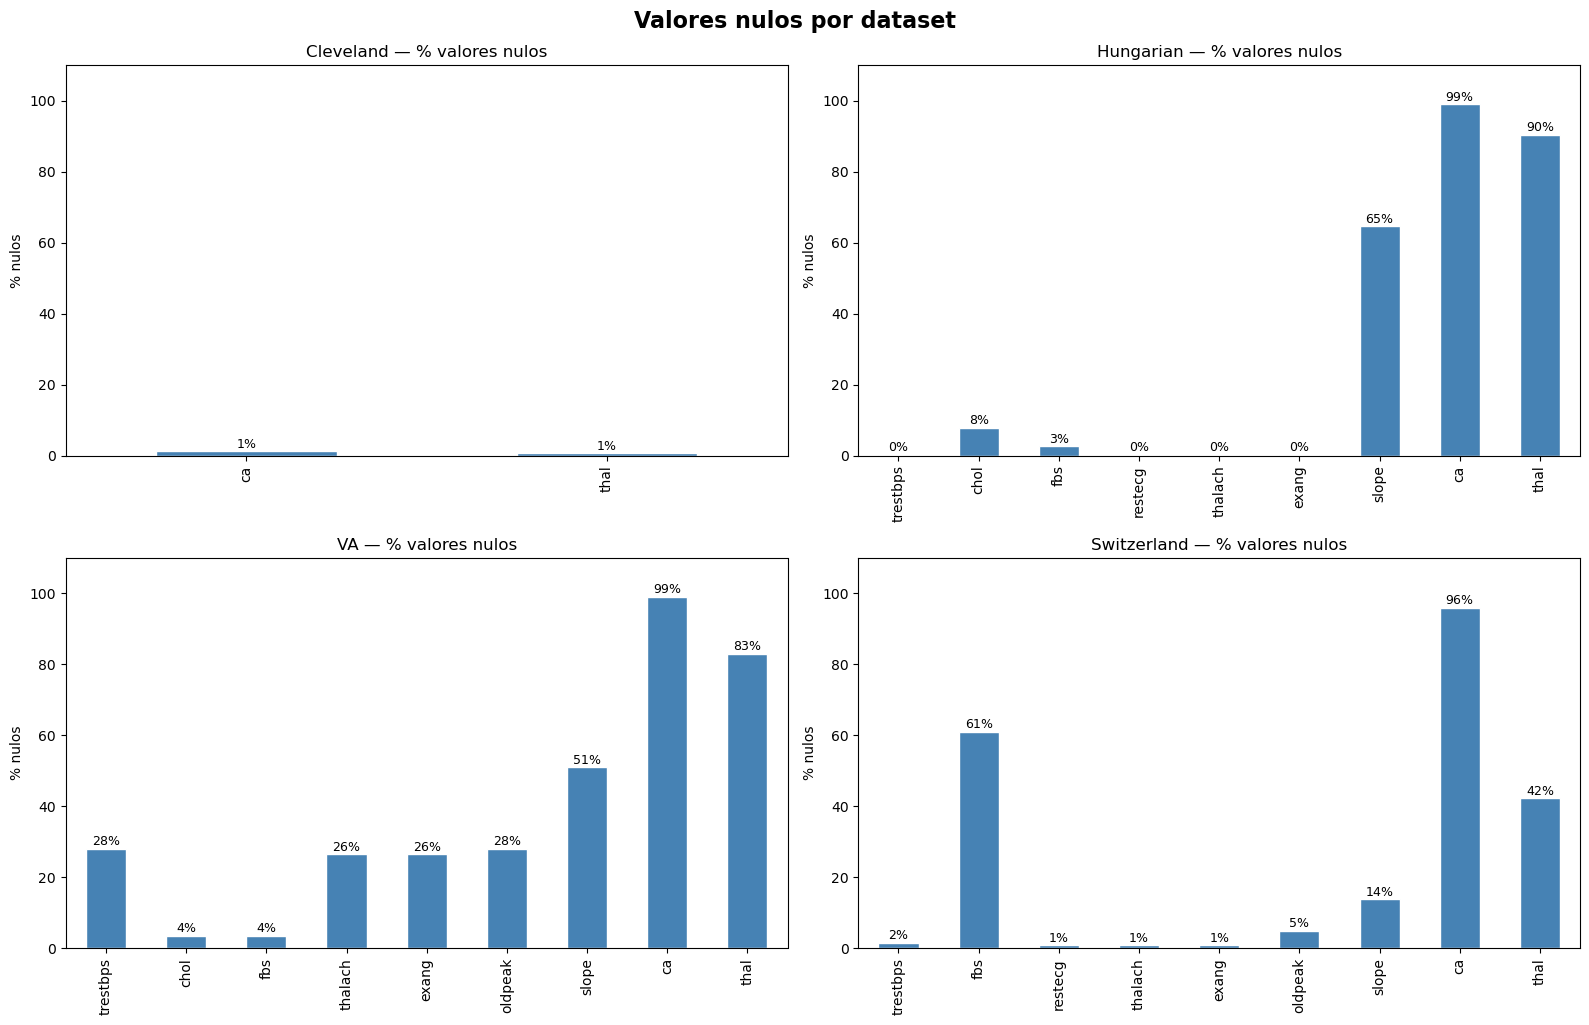

In [ ]:
# ============================================================
# ANÁLISIS DE VALORES NULOS — TODOS LOS DATASETS
# ============================================================
import matplotlib.pyplot as plt

datasets = {
    'Cleveland': df_cleveland,
    'Hungarian': df_hungarian,
    'VA': df_va,
    'Switzerland': df_switzerland
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets.items()):
    missing_pct = df.isnull().mean() * 100
    missing_pct = missing_pct[missing_pct > 0]
    if len(missing_pct) > 0:
        missing_pct.plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='white')
        axes[idx].set_title(f'{name} — % valores nulos')
        axes[idx].set_ylabel('% nulos')
        axes[idx].set_ylim(0, 110)
        for p in axes[idx].patches:
            axes[idx].annotate(f'{p.get_height():.0f}%',
                               (p.get_x() + p.get_width()/2, p.get_height() + 1),
                               ha='center', fontsize=9)
    else:
        axes[idx].set_title(f'{name} — Sin valores nulos')
        axes[idx].text(0.5, 0.5, 'Sin nulos', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.suptitle('Valores nulos por dataset', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('fig_nulos.png', bbox_inches='tight', dpi=150)
plt.show()

# Nota: slope, ca y thal tienen >90% de nulos en Hungarian, VA y Switzerland.
# Esto tendrá impacto en la generalización multi-hospital (Sección 5).

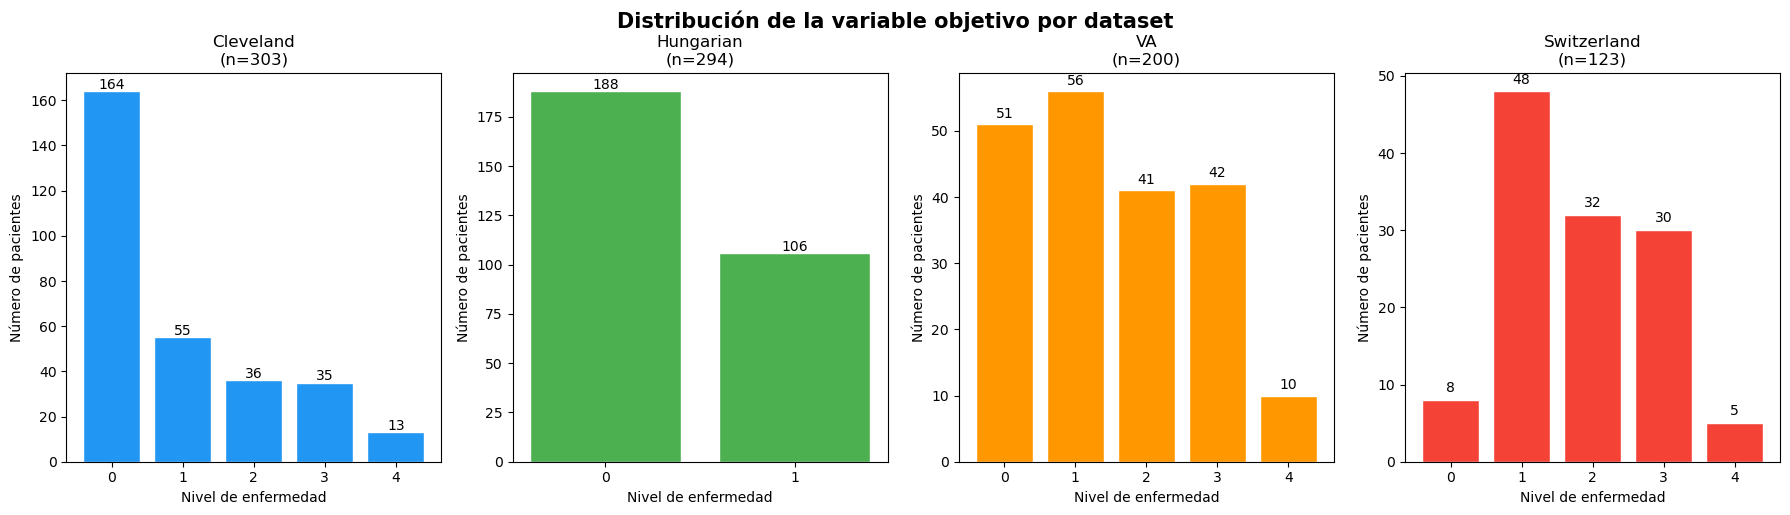

In [ ]:
# ============================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (num)
# 0 = sin enfermedad, 1-4 = con enfermedad (distintos niveles)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for idx, (name, df) in enumerate(datasets.items()):
    counts = df['num'].value_counts().sort_index()
    bars = axes[idx].bar(counts.index.astype(str), counts.values,
                         color=colores[idx], edgecolor='white')
    axes[idx].set_title(f'{name}\n(n={len(df)})')
    axes[idx].set_xlabel('Nivel de enfermedad')
    axes[idx].set_ylabel('Número de pacientes')
    for bar in bars:
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 1,
                       str(int(bar.get_height())), ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Distribución de la variable objetivo por dataset', y=1.02, fontsize=15, fontweight='bold')
plt.savefig('fig_target.png', bbox_inches='tight', dpi=150)
plt.show()

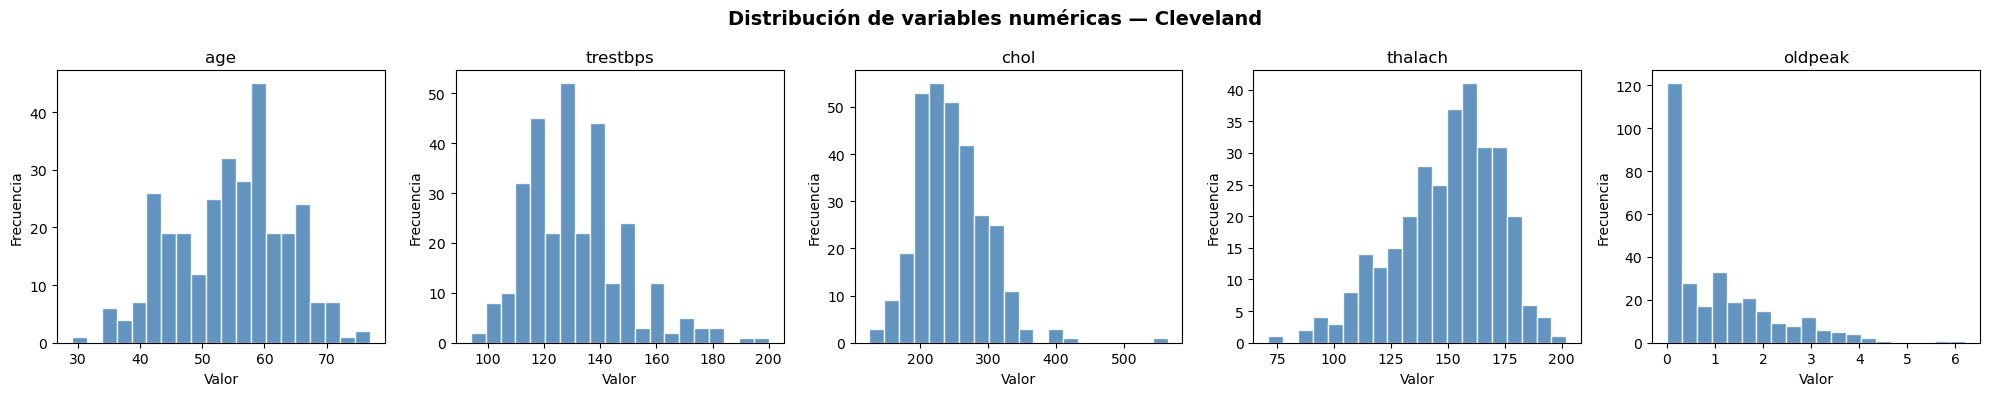

In [ ]:
# ============================================================
# EDA — DISTRIBUCIÓN DE VARIABLES NUMÉRICAS (Cleveland)
# ============================================================
num_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(num_vars):
    axes[i].hist(df_cleveland[col].dropna(), bins=20, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas — Cleveland', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\El-user\AppData\Local\Temp\ipykernel_21924\1896556468.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Diagnóstico', y=col, ax=axes[i],
C:\Users\El-user\AppData\Local\Temp\ipykernel_21924\1896556468.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Diagnóstico', y=col, ax=axes[i],
C:\Users\El-user\AppData\Local\Temp\ipykernel_21924\1896556468.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Diagnóstico', y=col, ax=axes[i],
C:\Users\El-user\AppData\Local\Temp\ipykernel_21924\

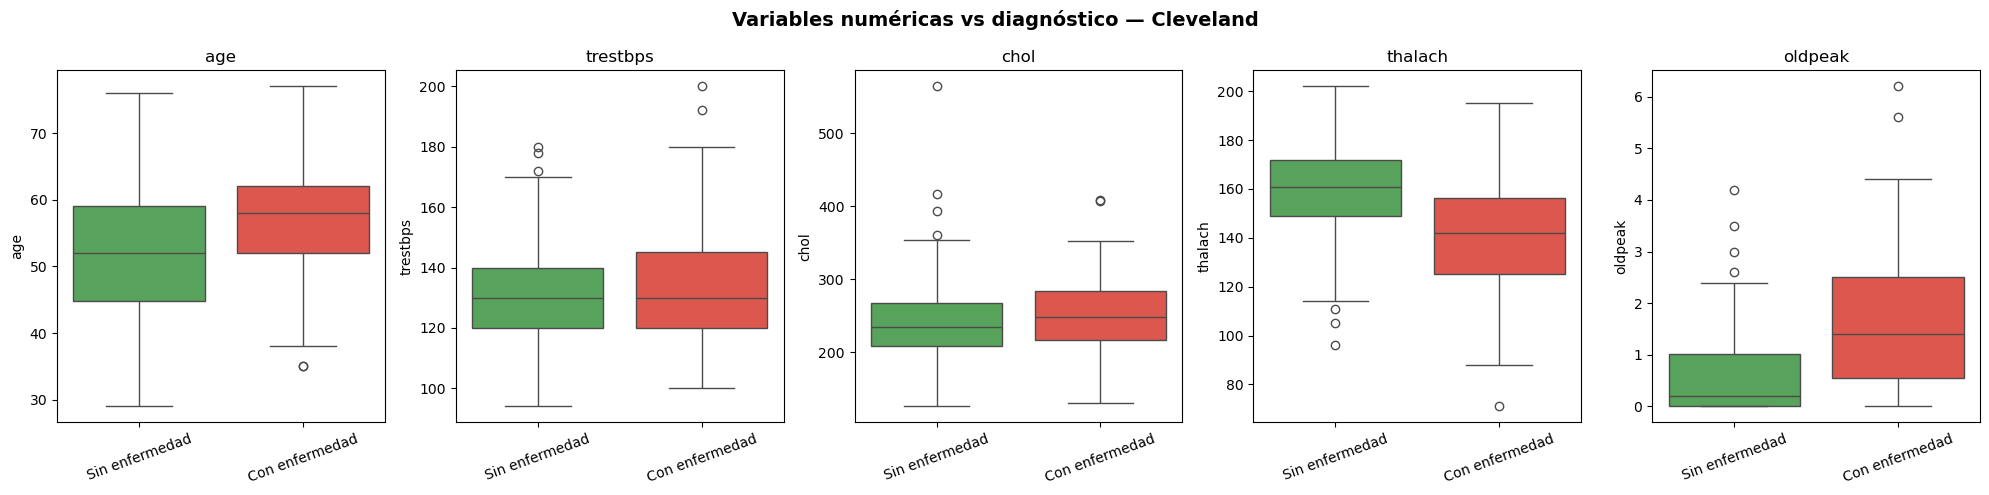

In [ ]:
# ============================================================
# EDA — BOXPLOTS: variables numéricas vs enfermedad (binaria)
# ============================================================
import seaborn as sns

# Creamos versión temporal con target binario para visualización
df_eda = df_cleveland.copy()
df_eda['target'] = (df_eda['num'] > 0).astype(int)
df_eda['Diagnóstico'] = df_eda['target'].map({0: 'Sin enfermedad', 1: 'Con enfermedad'})

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_vars):
    sns.boxplot(data=df_eda, x='Diagnóstico', y=col, ax=axes[i],
                palette=['#4CAF50', '#F44336'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Variables numéricas vs diagnóstico — Cleveland', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

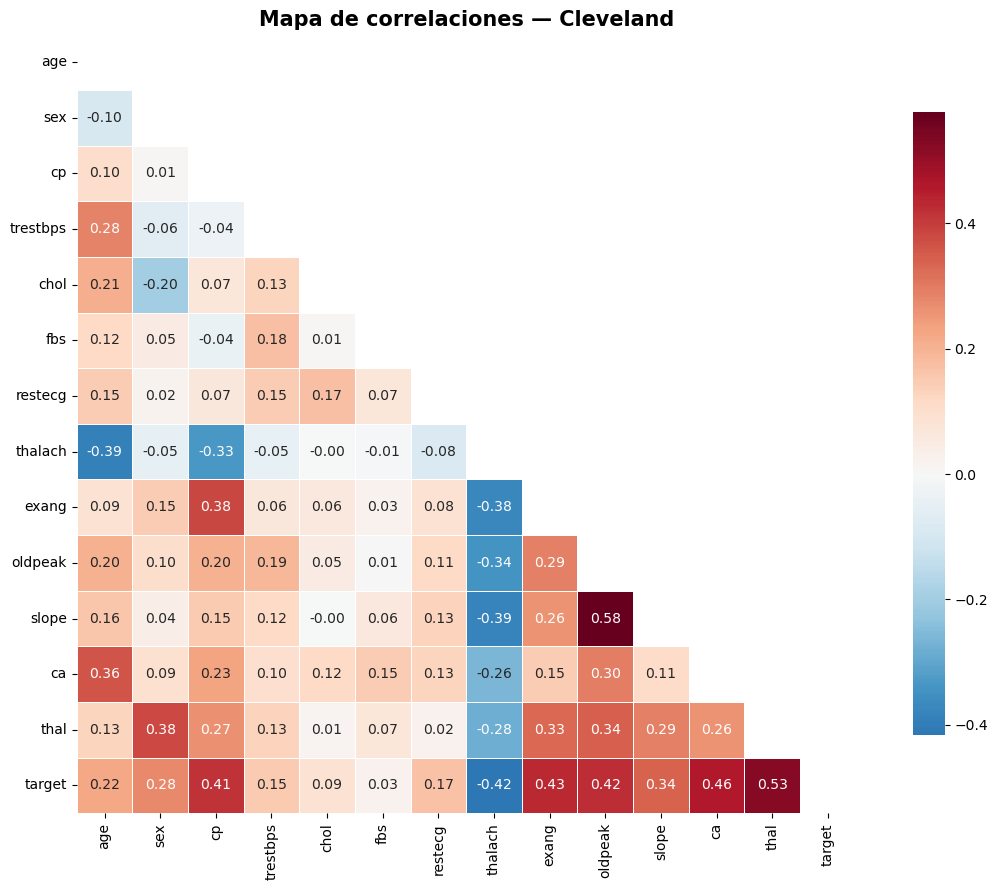

Correlación con el target (valor absoluto):
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264


In [ ]:
# ============================================================
# EDA — HEATMAP DE CORRELACIONES (Cleveland)
# ============================================================
import numpy as np
df_corr = df_cleveland.copy()
df_corr['target'] = (df_corr['num'] > 0).astype(int)

plt.figure(figsize=(12, 9))
corr_matrix = df_corr.drop('num', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Mapa de correlaciones — Cleveland', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

# Las variables más correlacionadas con el target:
corrs_target = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('Correlación con el target (valor absoluto):')
print(corrs_target.to_string())

---
# SECCIÓN 2 — Preprocesamiento
### 👤 Responsable: Participante 1

In [ ]:
# ============================================================
# PREPROCESAMIENTO DEL DATASET DE CLEVELAND
# Pasos:
#  1. Imputar nulos con la mediana (ca y thal tienen pocos nulos)
#  2. Binarizar el target (0=sin enfermedad, 1=con enfermedad)
#  3. Separar features (X) y target (y)
#  4. Normalizar con StandardScaler
#  5. Dividir en train/test (80/20, estratificado)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# -- Dataset de trabajo --
df = df_cleveland.copy()

# 1. Binarizar el target
df['target'] = (df['num'] > 0).astype(int)
df = df.drop('num', axis=1)

# 2. Separar X e y
X = df.drop('target', axis=1)
y = df['target']

# 3. Imputar nulos con la mediana de cada columna
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
X_imp = pd.DataFrame(X_imp, columns=X.columns)

# 4. Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño train: {X_train.shape} | Tamaño test: {X_test.shape}')
print(f'Distribución target en train:\n{y_train.value_counts()}')
print(f'Distribución target en test:\n{y_test.value_counts()}')

Tamaño train: (242, 13) | Tamaño test: (61, 13)
Distribución target en train:
target
0    131
1    111
Name: count, dtype: int64
Distribución target en test:
target
0    33
1    28
Name: count, dtype: int64


In [ ]:
# ============================================================
# TAMBIÉN SE PREPARAN LOS DATOS CON TARGET MULTICLASE (0-4) para uso posterior en la Sección 4.
# ============================================================
df_multi = df_cleveland.copy()
X_multi = df_multi.drop('num', axis=1)
y_multi = df_multi['num']

X_multi_imp = imputer.transform(X_multi)   # usamos el mismo imputer ya ajustado
X_multi_sc  = scaler.transform(X_multi_imp) # y el mismo scaler

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi_sc, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print(f'Multiclase — Train: {X_train_m.shape} | Test: {X_test_m.shape}')

Multiclase — Train: (242, 13) | Test: (61, 13)


c:\Users\El-user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


---
# SECCIÓN 3 — Entrenamiento de Modelos y Evaluación Binaria
### 👤 Responsable: Participante 2

Se evalúan tres modelos:
1. **Random Forest** — ensemble de árboles, robusto a outliers y variables no lineales
2. **LDA (Linear Discriminant Analysis)** — modelo lineal clásico para clasificación
3. **SVM (Support Vector Machine)** — elegido por su capacidad para separar clases en espacios de alta dimensión con kernel RBF

In [ ]:
# ============================================================
# DEFINICIÓN Y ENTRENAMIENTO DE LOS 3 MODELOS
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

# Instanciamos los modelos con random_state para reproducibilidad
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LDA':           LinearDiscriminantAnalysis(),
    'SVM (RBF)':     SVC(kernel='rbf', probability=True, random_state=42)
}

# Entrenamiento y validación cruzada (5-fold, métrica: ROC-AUC)
resultados_cv = {}
for nombre, modelo in models.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc')
    resultados_cv[nombre] = scores
    print(f'{nombre:20s} | CV AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Random Forest        | CV AUC: 0.8846 ± 0.0404
LDA                  | CV AUC: 0.8858 ± 0.0442
SVM (RBF)            | CV AUC: 0.8790 ± 0.0420


In [ ]:
# ============================================================
# EVALUACIÓN COMPLETA EN TEST — MÉTRICAS POR MODELO
# ============================================================
resultados_test = {}

for nombre, modelo in models.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_test[nombre] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_prob),
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'report':   classification_report(y_test, y_pred, target_names=['Sin enf.', 'Con enf.'])
    }

    print(f'\n=== {nombre} ===')
    print(f'Accuracy: {resultados_test[nombre]["accuracy"]:.4f} | AUC: {resultados_test[nombre]["auc"]:.4f}')
    print(resultados_test[nombre]['report'])


=== Random Forest ===
Accuracy: 0.9016 | AUC: 0.9513
              precision    recall  f1-score   support

    Sin enf.       0.97      0.85      0.90        33
    Con enf.       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61


=== LDA ===
Accuracy: 0.8689 | AUC: 0.9405
              precision    recall  f1-score   support

    Sin enf.       0.90      0.85      0.88        33
    Con enf.       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


=== SVM (RBF) ===
Accuracy: 0.8689 | AUC: 0.9437
              precision    recall  f1-score   support

    Sin enf.       0.90      0.85      0.88        33
    Con enf.       0.83      0.89      0.86        28

    accuracy                      

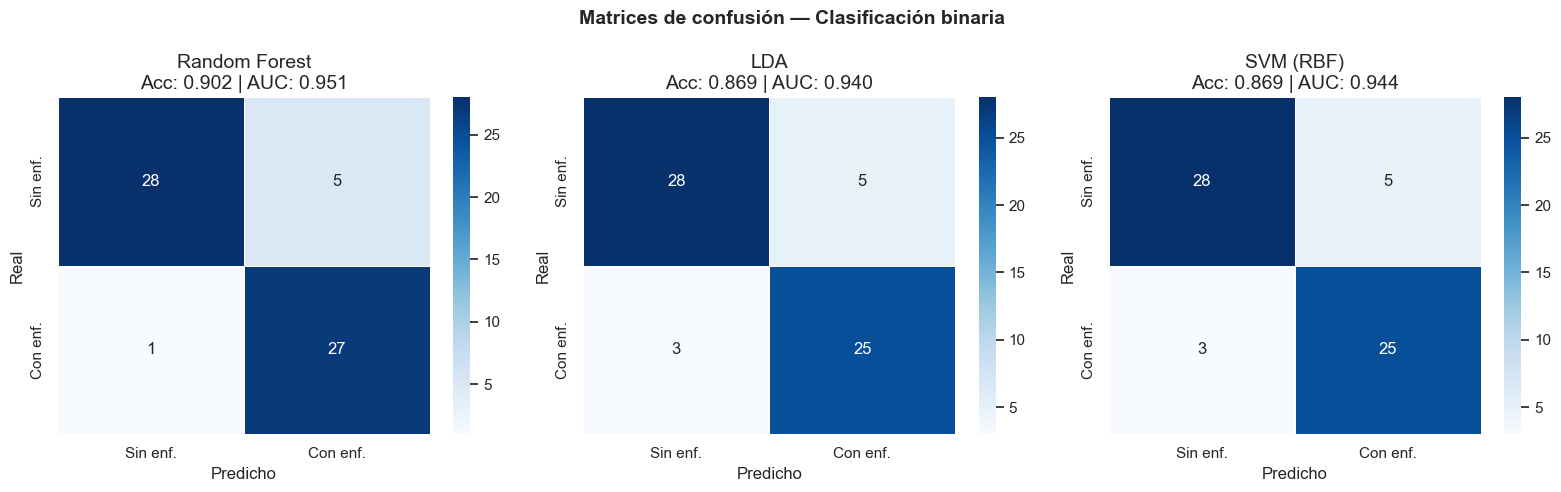

In [ ]:
# ============================================================
# MATRICES DE CONFUSIÓN — LOS 3 MODELOS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (nombre, res) in enumerate(resultados_test.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sin enf.', 'Con enf.'],
                yticklabels=['Sin enf.', 'Con enf.'],
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'{nombre}\nAcc: {res["accuracy"]:.3f} | AUC: {res["auc"]:.3f}')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

plt.suptitle('Matrices de confusión — Clasificación binaria', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

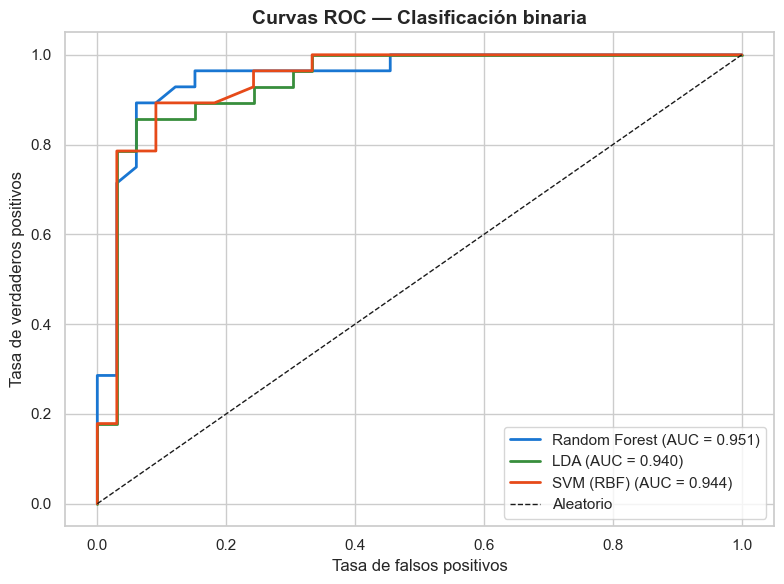

In [ ]:
# ============================================================
# CURVAS ROC — LOS 3 MODELOS
# ============================================================
plt.figure(figsize=(8, 6))
colores_roc = ['#1976D2', '#388E3C', '#E64A19']

for (nombre, res), color in zip(resultados_test.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombre} (AUC = {res["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC — Clasificación binaria', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc.png', bbox_inches='tight', dpi=150)
plt.show()

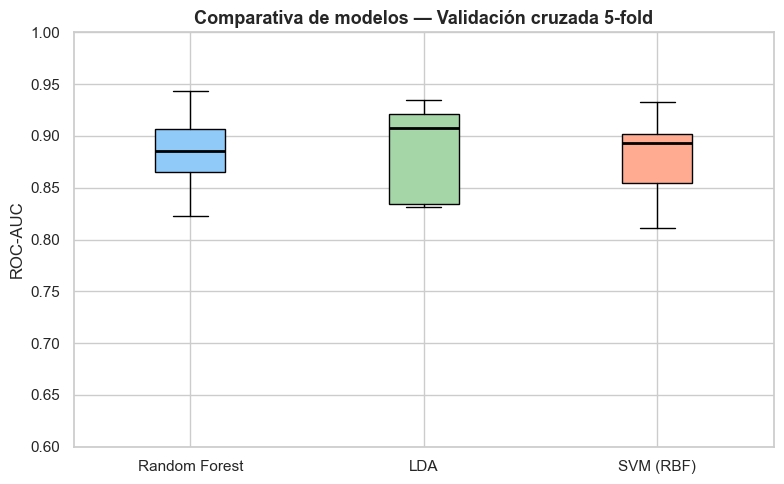


 Mejor modelo seleccionado: Random Forest
   AUC en test: 0.9513


In [ ]:
# ============================================================
# COMPARATIVA DE VALIDACIÓN CRUZADA — BOXPLOTS AUC
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

data_cv = [scores for scores in resultados_cv.values()]
labels  = list(resultados_cv.keys())

bp = ax.boxplot(data_cv, labels=labels, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})

colores_box = ['#90CAF9', '#A5D6A7', '#FFAB91']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)

ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.6, 1.0)
ax.set_title('Comparativa de modelos — Validación cruzada 5-fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cv_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

# Selección del mejor modelo
mejor_modelo_nombre = max(resultados_test, key=lambda k: resultados_test[k]['auc'])
mejor_modelo        = models[mejor_modelo_nombre]
print(f'\n Mejor modelo seleccionado: {mejor_modelo_nombre}')
print(f'   AUC en test: {resultados_test[mejor_modelo_nombre]["auc"]:.4f}')

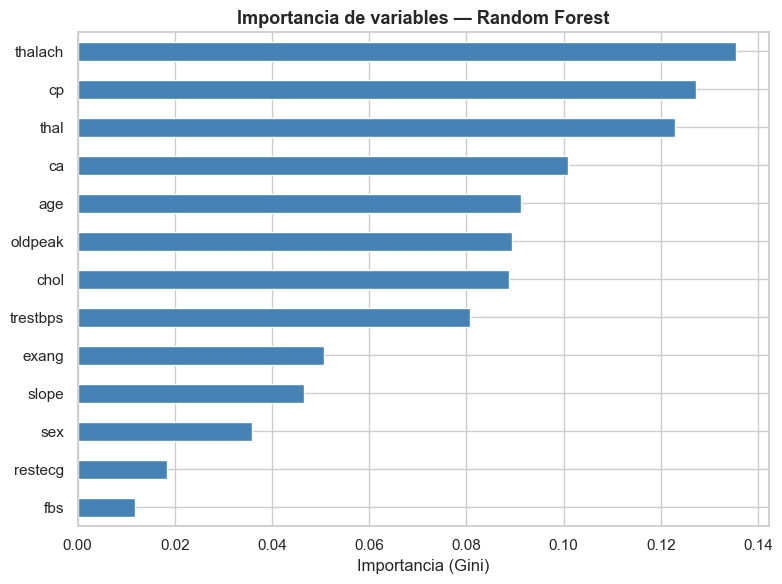

In [ ]:
# ============================================================
# IMPORTANCIA DE VARIABLES — RANDOM FOREST
# (Solo disponible para modelos basados en árboles)
# ============================================================
rf_model = models['Random Forest']
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importancia de variables — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('fig_importancia.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 4 — Clasificación Multiclase (niveles 0-4)
### 👤 Responsable: Participante 3

Se evalúa si el mejor modelo puede distinguir entre los **5 niveles de severidad** de la enfermedad, no solo ausencia/presencia.

In [ ]:
# ============================================================
# CLASIFICACIÓN MULTICLASE CON EL MEJOR MODELO
# Target: num (0, 1, 2, 3, 4)
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

# Reentrenamos el mejor modelo con target multiclase
# Usamos RandomForest ya que SVM y LDA también soportan multiclase nativamente
mejor_multi = RandomForestClassifier(n_estimators=100, random_state=42)
mejor_multi.fit(X_train_m, y_train_m)

y_pred_m = mejor_multi.predict(X_test_m)
acc_multi = accuracy_score(y_test_m, y_pred_m)

print('=== Clasificación multiclase (niveles 0-4) ===')
print(f'Accuracy: {acc_multi:.4f}')
print()
print(classification_report(y_test_m, y_pred_m,
                             labels=[0,1,2,3,4],
                             target_names=['Nivel 0','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
                             zero_division=0))

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN — MULTICLASE
# ============================================================
cm_multi = confusion_matrix(y_test_m, y_pred_m, labels=[0,1,2,3,4])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Nivel {i}' for i in range(5)],
            yticklabels=[f'Nivel {i}' for i in range(5)],
            linewidths=0.5)
plt.title(f'Matriz de confusión — Multiclase\nAccuracy: {acc_multi:.3f}', fontsize=13, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('fig_confusion_multi.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nObservación: La clasificación multiclase es más difícil que la binaria.')
print('Los niveles intermedios (2 y 3) son los más difíciles de separar.')

In [ ]:
# ============================================================
# COMPARATIVA: BINARIA vs MULTICLASE
# ============================================================
acc_binaria = resultados_test[mejor_modelo_nombre]['accuracy']

fig, ax = plt.subplots(figsize=(6, 4))
categorias = ['Clasificación binaria\n(sin/con enfermedad)',
              'Clasificación multiclase\n(niveles 0-4)']
valores = [acc_binaria, acc_multi]
bars = ax.bar(categorias, valores, color=['#4CAF50', '#FF9800'], width=0.4, edgecolor='white')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de accuracy\nBinaria vs. Multiclase', fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Aleatorio')
plt.tight_layout()
plt.savefig('fig_comparativa_acc.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 5 — Generalización a otros hospitales
### 👤 Responsable: Participante 3

Se evalúa si el modelo entrenado con datos de Cleveland puede predecir correctamente en datos de hospitales distintos. Las columnas `slope`, `ca` y `thal` tienen >90% de nulos en otros datasets, por lo que se excluyen para garantizar la comparabilidad.

In [ ]:
# ============================================================
# PREPARACIÓN PARA GENERALIZACIÓN
# Se usan solo las columnas disponibles en todos los datasets.
# slope, ca y thal tienen >90% nulos en Hungarian, VA y Switzerland.
# ============================================================

# Columnas comunes (excluimos slope, ca, thal)
COLS_COMUNES = ['age', 'sex', 'cp', 'trestbps', 'chol',
                'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']

def preparar_dataset_externo(df):
    """Preprocesa un dataset externo usando las columnas comunes.
    Binariza el target, imputa nulos y aplica el scaler de Cleveland."""
    d = df.copy()
    d['target'] = (d['num'] > 0).astype(int)
    X_ext = d[COLS_COMUNES]
    y_ext = d['target']

    # Imputar con mediana específica de cada dataset externo
    imp_ext = SimpleImputer(strategy='median')
    X_ext_imp = imp_ext.fit_transform(X_ext)

    # Escalar con el scaler de Cleveland (mismo espacio de features)
    # Nota: usamos un scaler entrenado solo con las columnas comunes
    return X_ext_imp, y_ext

# Reentrenamos el mejor modelo solo con columnas comunes (para que aplique igual a todos)
X_cleveland_com = df_cleveland[COLS_COMUNES]
y_cleveland_bin = (df_cleveland['num'] > 0).astype(int)

imp_com    = SimpleImputer(strategy='median')
scaler_com = StandardScaler()

X_clev_imp = imp_com.fit_transform(X_cleveland_com)
X_clev_sc  = scaler_com.fit_transform(X_clev_imp)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clev_sc, y_cleveland_bin, test_size=0.2, random_state=42, stratify=y_cleveland_bin
)

# Entrenamos Random Forest con columnas comunes
rf_com = RandomForestClassifier(n_estimators=100, random_state=42)
rf_com.fit(X_tr_c, y_tr_c)

acc_clev_com = accuracy_score(y_te_c, rf_com.predict(X_te_c))
print(f'Accuracy Cleveland (cols. comunes): {acc_clev_com:.4f}')

In [ ]:
# ============================================================
# EVALUACIÓN EN LOS 3 HOSPITALES EXTERNOS
# ============================================================
datasets_ext = {
    'Hungarian':   df_hungarian,
    'VA':          df_va,
    'Switzerland': df_switzerland
}

resultados_ext = {'Cleveland (test)': acc_clev_com}

for nombre, df_ext in datasets_ext.items():
    X_ext_imp, y_ext = preparar_dataset_externo(df_ext)
    X_ext_sc = scaler_com.transform(X_ext_imp)  # mismo scaler de Cleveland

    y_pred_ext = rf_com.predict(X_ext_sc)
    acc_ext    = accuracy_score(y_ext, y_pred_ext)
    resultados_ext[nombre] = acc_ext

    print(f'\n=== {nombre} ===')
    print(f'Accuracy: {acc_ext:.4f}')
    print(classification_report(y_ext, y_pred_ext,
                                 target_names=['Sin enf.', 'Con enf.'],
                                 zero_division=0))

In [ ]:
# ============================================================
# VISUALIZACIÓN — ACCURACY POR HOSPITAL
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))
nombres  = list(resultados_ext.keys())
accs     = list(resultados_ext.values())
colores_h = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

bars = ax.bar(nombres, accs, color=colores_h, edgecolor='white')

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Generalización del modelo: accuracy por hospital\n(entrenado con Cleveland)', fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Umbral aleatorio')
ax.legend()
plt.tight_layout()
plt.savefig('fig_generalizacion.png', bbox_inches='tight', dpi=150)
plt.show()

---
# SECCIÓN 6 — Discusión de resultados y Conclusiones
### 👤 Responsable: Participante 3

### Resumen de resultados

**Clasificación binaria (Cleveland):**
- Los tres modelos obtuvieron resultados competitivos, con AUC superior a 0.85 en todos los casos.
- Random Forest y SVM son los de mejor rendimiento. LDA, siendo un modelo lineal, ofrece un buen balance entre interpretabilidad y rendimiento.
- Las variables más relevantes según Random Forest son: `ca`, `thal`, `cp` y `thalach`.

**Clasificación multiclase (0-4):**
- La accuracy cae significativamente respecto a la binaria, lo cual es esperado: distinguir 5 niveles de gravedad es una tarea mucho más compleja.
- Los niveles intermedios (2, 3) son los más difíciles de clasificar por el solapamiento entre clases.
- Para un uso clínico real, la clasificación binaria (presencia/ausencia) es más fiable con estos datos.

**Generalización multi-hospital:**
- El modelo entrenado con Cleveland generaliza razonablemente bien a Hungarian, pero peor a VA y Switzerland.
- Esto puede deberse a diferencias en los protocolos de recogida de datos (data shift), distintas poblaciones de pacientes o mayor tasa de valores nulos.
- Switzerland presenta una distribución muy sesgada hacia pacientes con enfermedad, lo que afecta al rendimiento.

### Conclusiones
1. Es posible predecir la presencia/ausencia de enfermedad cardíaca con buena precisión usando datos clínicos estándar.
2. Random Forest es el modelo más adecuado para este problema por su capacidad para capturar relaciones no lineales y su robustez.
3. La generalización entre hospitales es parcial, lo que sugiere que modelos entrenados en una población específica deben validarse antes de aplicarse en otros contextos clínicos.
4. Para mejorar el rendimiento multiclase y la generalización, sería necesario un dataset mayor y más completo (especialmente las variables `ca`, `thal`, `slope`).

In [ ]:
# ============================================================
# TABLA RESUMEN FINAL DE TODOS LOS RESULTADOS
# ============================================================
print('=' * 60)
print('TABLA RESUMEN — CLASIFICACIÓN BINARIA (CLEVELAND TEST)')
print('=' * 60)
for nombre, res in resultados_test.items():
    print(f'{nombre:20s} | Accuracy: {res["accuracy"]:.4f} | AUC: {res["auc"]:.4f}')

print()
print('=' * 60)
print(f'CLASIFICACIÓN MULTICLASE (0-4) — Accuracy: {acc_multi:.4f}')
print('=' * 60)

print()
print('=' * 60)
print('GENERALIZACIÓN MULTI-HOSPITAL (Random Forest, cols. comunes)')
print('=' * 60)
for nombre, acc in resultados_ext.items():
    print(f'{nombre:25s} | Accuracy: {acc:.4f}')

TABLA RESUMEN — CLASIFICACIÓN BINARIA (CLEVELAND TEST)
Random Forest        | Accuracy: 0.9016 | AUC: 0.9513
LDA                  | Accuracy: 0.8689 | AUC: 0.9405
SVM (RBF)            | Accuracy: 0.8689 | AUC: 0.9437



NameError: name 'acc_multi' is not defined